In [251]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
data_path = Path("/content/titanic.csv") # change to path folder with data

# 1. Oczyszczenie tabeli

In [252]:
titanic_df = pd.read_csv(data_path, index_col="PassengerId")
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Zacznijmy od sprawdzenia gdzie występują braki w danych

In [253]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


Możemy zaobserwować, że:


*   Kolumna Cabin jest pełna braków i informacje w niej byłyby ciężkie do zgadnięcia, dlatego zostanie usunięta
*   W mojej ocenie kolumny Name oraz Ticket nic nam nie wnoszą
*   W kolumnie Fare braki będą uśredniane, gdyż cena za bilet raczej nie wpływa na kwestie przeżywalności
*   Kolumnę Age uzupełnię średnim wiekiem dla każdej płci
*   Kolumnę Embarked występują tylko 2 braki, dlatego zastąpię je dominantą

In [254]:
# usunięcie Cabin, Name, Ticket

titanic_df.drop(columns=["Cabin", "Name", "Ticket"], inplace = True)

In [255]:
# przydzielanie wieku wobec płci

avg_age = np.floor(titanic_df.groupby("Sex")["Age"].mean())
mask_female = (titanic_df["Sex"] == "female") & (titanic_df["Age"].isna())
mask_male = (titanic_df["Sex"] == "male") & (titanic_df["Age"].isna())

titanic_df.loc[mask_female, "Age"] = avg_age["female"]
titanic_df.loc[mask_male, "Age"] = avg_age["male"]

In [256]:
# uzupełnianie braków w kolumnie Fare

titanic_df["Fare"].fillna(titanic_df["Fare"].mean(), inplace = True)

/tmp/ipykernel_3605/3970224352.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df["Fare"].fillna(titanic_df["Fare"].mean(), inplace = True)


In [257]:
# uzupełnianie braków w kolumnie Embarked

mode_embarked = titanic_df["Embarked"].mode()[0]
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(mode_embarked)

Upewnijmy się czy jeszcze gdzieś występują jakieś braki

In [258]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# 2. Dodatkowe kolumny

Dodam dwie nowe kolumny:


*   Pierwszą kolumną będzie **SizeOfFamily** czyli **SibSp+Parch+1**, suma wszystkich członków rodziny
*   Drugą kolumną natomiast będzie podział osób na kategorie wiekowe {dzieci -> [0;17], dorośli -> [18;59], seniorzy -> [60;∞)}



In [259]:
# funkcja do kategoryzowania na podstawie wieku

def categorize_age(age):
    if age <= 17:
        return "Child"
    elif 18 <= age <= 59:
        return "Adult"
    else:
        return "Senior"

In [260]:
# dodajemy kolumny

titanic_df["GroupByAge"] = titanic_df["Age"].apply(categorize_age) # GroupByAge
titanic_df["SizeOfFamily"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1 # SizeOfFamily

In [261]:
titanic_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,GroupByAge,SizeOfFamily
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.250000,S,Adult,2
2,1,1,female,38.0,1,0,71.283300,C,Adult,2
3,1,3,female,26.0,0,0,7.925000,S,Adult,1
4,1,1,female,35.0,1,0,53.100000,S,Adult,2
5,0,3,male,35.0,0,0,8.050000,S,Adult,1
6,0,3,male,30.0,0,0,8.458300,Q,Adult,1
7,0,1,male,54.0,0,0,51.862500,S,Adult,1
8,0,3,male,2.0,3,1,21.075000,S,Child,5
9,1,3,female,27.0,0,2,33.123938,S,Adult,3


# 3. Kodowanie cech kategorialnych

Z danych możemy wywnioskować, że naszymi danymi kategorialnymi do zakodowania będą kolumny: Sex, Embarked oraz GroupByAge

In [262]:
# kodowanie Sex - label encoding

titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})

In [263]:
# kodowanie GroupByAge - label encoding

titanic_df["GroupByAge"] = titanic_df["GroupByAge"].map({"Child": 0, "Adult": 1, "Senior": 2})

In [264]:
# kodowanie Embarked - one-hot encoding

embarked_dummies = pd.get_dummies(titanic_df["Embarked"], prefix="Embarked", dtype=int)
titanic_df = pd.concat([titanic_df, embarked_dummies], axis=1) # zostawiam kolumnę Embarked dla późniejszej wizualizacji (podejrzewam że pewnie do późniejszych zadań lepiej usunąć)

# 4. Outliers

In [265]:
titanic_df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,GroupByAge,SizeOfFamily,Embarked_C,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.580438,0.523008,0.381594,33.123938,0.902357,1.904602,0.188552,0.086420,0.725028
std,0.486592,0.836071,0.477990,13.018631,1.102743,0.806057,48.655811,0.382929,1.613459,0.391372,0.281141,0.446751
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,8.050000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000,30.000000,0.000000,0.000000,19.258300,1.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,33.123938,1.000000,2.000000,0.000000,0.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,11.000000,1.000000,1.000000,1.000000


Odchylenie standardowe dla Age oraz Fare jest największe, dlatego te kolumny zbadamy

In [266]:
# Age outliers

Q1 = titanic_df["Age"].quantile(0.25)
Q3 = titanic_df["Age"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_age = titanic_df[(titanic_df["Age"] < lower_bound) | (titanic_df["Age"] > upper_bound)]
outliers_age

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,GroupByAge,SizeOfFamily,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
8,0,3,0,2.00,3,1,21.0750,S,0,5,0,0,1
12,1,1,1,58.00,0,0,26.5500,S,1,1,0,0,1
16,1,2,1,55.00,0,0,16.0000,S,1,1,0,0,1
17,0,3,0,2.00,4,1,29.1250,Q,0,6,0,1,0
34,0,2,0,66.00,0,0,10.5000,S,2,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,1,2,0,1.00,0,2,37.0042,C,0,3,1,0,0
830,1,1,1,62.00,0,0,80.0000,S,2,1,0,0,1
832,1,2,0,0.83,1,1,18.7500,S,0,3,0,0,1


In [267]:
# Fare outliers

Q1 = titanic_df["Fare"].quantile(0.25)
Q3 = titanic_df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_age = titanic_df[(titanic_df["Fare"] < lower_bound) | (titanic_df["Fare"] > upper_bound)]
outliers_age

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,GroupByAge,SizeOfFamily,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
2,1,1,1,38.0,1,0,71.2833,C,1,2,1,0,0
28,0,1,0,19.0,3,2,263.0000,S,1,6,0,0,1
32,1,1,1,27.0,1,0,146.5208,C,1,2,1,0,0
53,1,1,1,49.0,1,0,76.7292,C,1,2,1,0,0
62,1,1,1,38.0,0,0,80.0000,S,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,1,1,1,62.0,0,0,80.0000,S,2,1,0,0,1
836,1,1,1,39.0,1,1,83.1583,C,1,3,1,0,0
850,1,1,1,27.0,1,0,89.1042,C,1,2,1,0,0


# 5. Wizualizacja

In [268]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,GroupByAge,SizeOfFamily,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,S,1,2,0,0,1
2,1,1,1,38.0,1,0,71.2833,C,1,2,1,0,0
3,1,3,1,26.0,0,0,7.9250,S,1,1,0,0,1
4,1,1,1,35.0,1,0,53.1000,S,1,2,0,0,1
5,0,3,0,35.0,0,0,8.0500,S,1,1,0,0,1


Diagram słupkowy rozkładu ile ludzi przetrwało, a ilu nie

Text(0.5, 1.0, 'Distribution of survived')

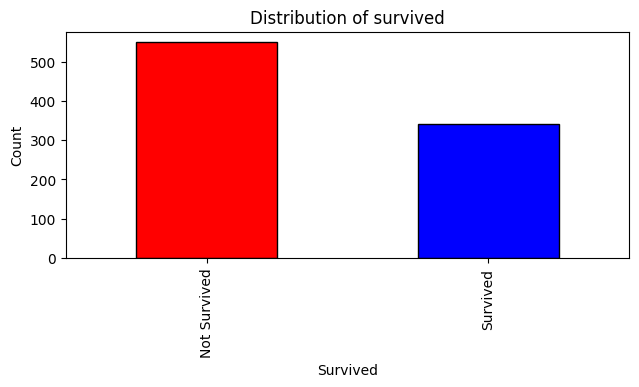

In [269]:
# diagram przetrwania

plt.figure(figsize=(16, 10))
survived_counts = titanic_df["Survived"].value_counts()
plt.subplot(3, 2, 1)
survived_counts.plot(kind="bar", color=["red", "blue"], edgecolor="black")
plt.xticks(range(2), ["Not Survived", "Survived"])
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Distribution of survived")

Diagram słupkowy przedstawiający liczbę biletów z podziałem na klasy biletów

Text(0.5, 1.0, 'Distribution of Pclass')

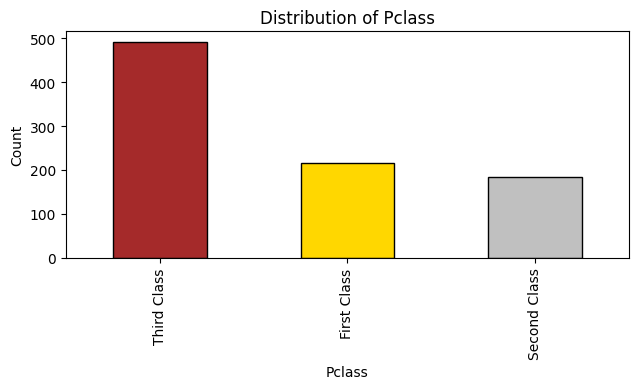

In [270]:
# diagram klasy biletów

plt.figure(figsize=(16, 10))
pclass_counts = titanic_df["Pclass"].value_counts()
plt.subplot(3, 2, 1)
pclass_counts.plot(kind="bar", color=["brown", "gold", "silver"], edgecolor="black")
plt.xticks(range(0, 3), ["Third Class", "First Class", "Second Class"])
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.title("Distribution of Pclass")

Diagram przedstawiający ile było mężczyzn i kobiet w poszczególnym wieku

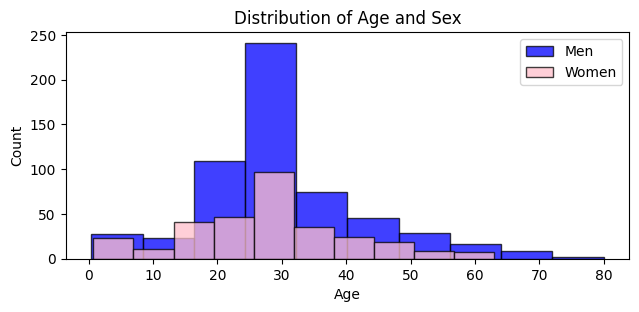

In [271]:
# diagram płeć względem wieku

plt.figure(figsize=(16, 10))
male_counts = titanic_df[titanic_df["Sex"] == 0]["Age"]
female_counts = titanic_df[titanic_df["Sex"] == 1]["Age"]
plt.subplot(3, 2, 1)
plt.hist(male_counts, bins=10, alpha=0.75, label="Men", color="blue", edgecolor="black")
plt.hist(female_counts, bins=10, alpha=0.75, label="Women", color="pink", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age and Sex")
plt.legend()

Diagram przedstawiający ile było biletów w konkretnej cenie

Text(0.5, 1.0, 'Distribution of Fare')

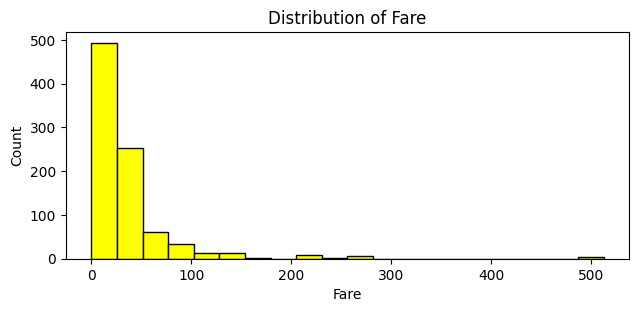

In [272]:
# diagram ceny biletów

plt.figure(figsize=(16, 10))
fare_counts = titanic_df["Fare"]
plt.subplot(3, 2, 1)
plt.hist(fare_counts, bins=20, color='yellow', edgecolor = 'black')
plt.xlabel("Fare")
plt.ylabel("Count")
plt.title("Distribution of Fare")

Diagram przedstawiający ile osób wysiadło w konkretnych portach

Text(0.5, 1.0, 'Distribution of Embarked')

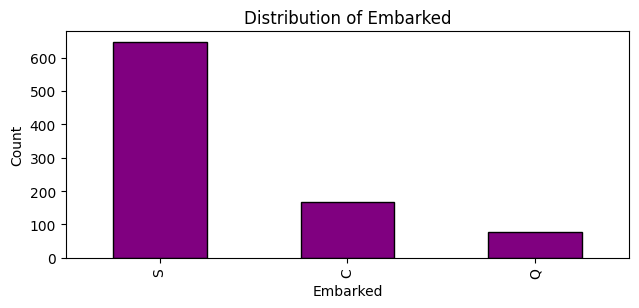

In [273]:
# diagram Embarked

plt.figure(figsize=(16, 10))
embarked_counts = titanic_df["Embarked"].value_counts()
plt.subplot(3, 2, 1)
embarked_counts.plot(kind="bar", color="purple", edgecolor="black")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.title("Distribution of Embarked")

Diagram przedstawiający liczebność rodzin

Text(0.5, 1.0, 'Distribution of Family Sizes')

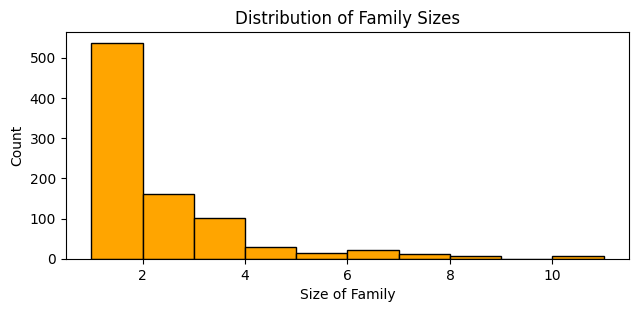

In [274]:
# diagram SizeOfFamily

plt.figure(figsize=(16, 10))
sizes_counts = titanic_df["SizeOfFamily"]
plt.subplot(3, 2, 1)
plt.hist(sizes_counts, bins=10, color="orange", edgecolor="black")
plt.xlabel("Size of Family")
plt.ylabel("Count")
plt.title("Distribution of Family Sizes")

Diagram przedstawiący liczbę ludzi należących do danej grupy wiekowej

Text(0.5, 1.0, "Distribution of Age's groups")

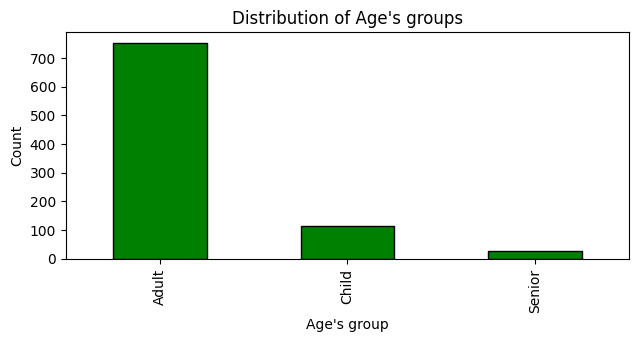

In [275]:
# diagram GroupByAge

plt.figure(figsize=(16, 10))
age_counts = titanic_df["GroupByAge"].value_counts()
plt.subplot(3, 2, 1)
age_counts.plot(kind="bar", color="green", edgecolor="black")
plt.xticks(range(0, 3), ["Adult", "Child", "Senior"])
plt.xlabel("Age's group")
plt.ylabel("Count")
plt.title("Distribution of Age's groups")

Diagramy przedstawiające rozkład posiadanej liczby rodzeństwa i małżonków (**SibSp**) oraz liczby rodziców i dzieci (**Parch**) na pokładzie

Text(0.5, 1.0, 'Distribution of number of parents and children')

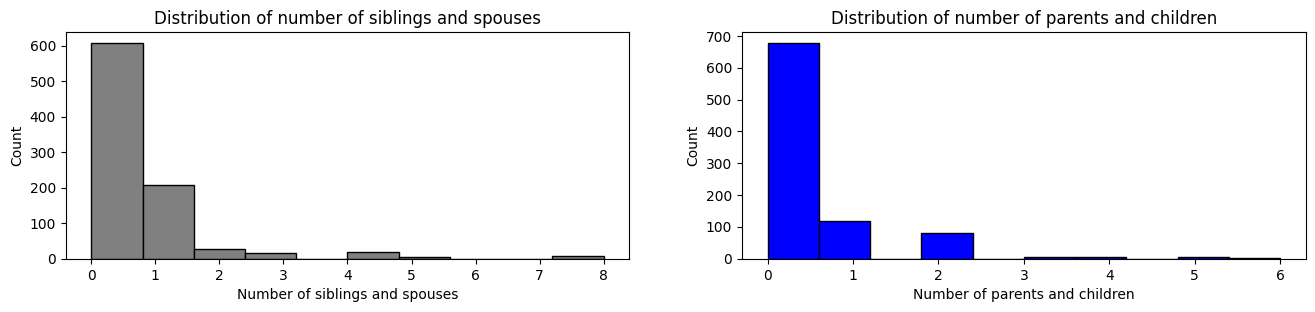

In [276]:
plt.figure(figsize=(16, 10))

# diagram SibSp

sibSp_counts = titanic_df["SibSp"]
plt.subplot(3, 2, 1)
plt.hist(sibSp_counts, bins=10, color="grey", edgecolor="black")
plt.xlabel("Number of siblings and spouses")
plt.ylabel("Count")
plt.title("Distribution of number of siblings and spouses")

# diagram Parch

parch_counts = titanic_df["Parch"]
plt.subplot(3, 2, 2)
plt.hist(parch_counts, bins=10, color="blue", edgecolor="black")
plt.xlabel("Number of parents and children")
plt.ylabel("Count")
plt.title("Distribution of number of parents and children")